# Task-1

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score)

In [69]:
# load the dataset
df = pd.read_csv("AB_NYC_2019.csv")
print("Dataset shape:", df.shape)
display(df.head())
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())
df.info()
display(df.describe(include="all").T)

Dataset shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


Rows: 48895
Columns: 16

Column names:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-n

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,48895.0,NaN,NaN,NaN,19017143.23618,10983108.38561,2539.0,9471945.0,19677284.0,29152178.5,36487245.0
name,48879,47905,Hillside Hotel,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,48895.0,NaN,NaN,NaN,67620010.64661,78610967.032667,2438.0,7822033.0,30793816.0,107434423.0,274321313.0
host_name,48874,11452,Michael,417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,48895,5,Manhattan,21661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,48895,221,Williamsburg,3920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,48895.0,NaN,NaN,NaN,40.728949,0.05453,40.49979,40.6901,40.72307,40.763115,40.91306
longitude,48895.0,NaN,NaN,NaN,-73.95217,0.046157,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299
room_type,48895,3,Entire home/apt,25409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,48895.0,NaN,NaN,NaN,152.720687,240.15417,0.0,69.0,106.0,175.0,10000.0


In [70]:
# check missing values
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df) * 100)
})

missing = missing.sort_values(
    "Missing Values",
    ascending=False)

display(missing)

# remove duplicates
print("Duplicate rows before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate rows after:", df.duplicated().sum())

# remove target column
print("Invalid prices:", (df["price"] <= 0).sum())
df = df[df["price"] > 0]

# remove invalid values
print(
    "Invalid minimum nights:",
    (df["minimum_nights"] <= 0).sum() )
df = df[df["minimum_nights"] > 0]

print(
    "Invalid availability:",
    ( (df["availability_365"] < 0) |
        (df["availability_365"] > 365)
    ).sum()  )
df = df[
    (df["availability_365"] >= 0) &
    (df["availability_365"] <= 365) ]

# drop unnecessary columns
df = df.drop(["id", "host_id", "host_name"], axis=1)
print("Remaining columns:")
print(df.columns.tolist())

,Missing Values,Missing Percentage
last_review,10052,20.558339
reviews_per_month,10052,20.558339
host_name,21,0.042949
name,16,0.032723
neighbourhood_group,0,0.000000
neighbourhood,0,0.000000
id,0,0.000000
host_id,0,0.000000
longitude,0,0.000000
latitude,0,0.000000


Duplicate rows before: 0
Duplicate rows after: 0
Invalid prices: 11
Invalid minimum nights: 0
Invalid availability: 0
Remaining columns:
['name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [71]:
X = df.drop("price", axis=1)
y = df["price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

X shape: (48884, 12)
y shape: (48884,)
Training set: (39107, 12)
Testing set: (9777, 12)


In [72]:
def feature_engineering(data):
    data = data.copy()

    # Name-based features
    data["name"] = data["name"].fillna("")
    data["name_length"] = data["name"].str.len()
    data["name_word_count"] = (data["name"].str.split().str.len() )

    data["name_char_count_no_space"] = (
        data["name"]
        .str.replace(" ", "", regex=False)
        .str.len() )

    name_lower = data["name"].str.lower()

    data["has_luxury"] = (
        name_lower
        .str.contains(
        "luxury|luxurious|premium|exclusive",
        regex=True)
        .astype(int) )

    data["has_view"] = (
        name_lower
        .str.contains(
        "view|views|ocean|skyline",
        regex=True)
        .astype(int) )

    data["has_private"] = (
        name_lower
        .str.contains(
        "private",
        regex=False)
        .astype(int) )

    data["has_studio"] = (
        name_lower
        .str.contains(
        "studio",
        regex=False)
        .astype(int) )

    data["has_bedroom"] = (
        name_lower
        .str.contains(
        "bedroom|br|bdrm",
        regex=True)
        .astype(int) )

    data["has_pool"] = (
        name_lower
        .str.contains(
        "pool",
        regex=False)
        .astype(int) )

    # Review features
    data["has_reviews"] = (data["number_of_reviews"] > 0).astype(int)

    # Availability feature
    data["availability_ratio"] = (
        data["availability_365"] / 365)

    # Log transformations
    data["minimum_nights_log"] = np.log1p(
        data["minimum_nights"] )

    data["number_of_reviews_log"] = np.log1p(
        data["number_of_reviews"] )

    data["reviews_per_month_log"] = np.log1p(
        data["reviews_per_month"] )

    data["host_listings_log"] = np.log1p(
        data["calculated_host_listings_count"] )

    return data

X_train = feature_engineering(X_train)
X_test = feature_engineering(X_test)
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features: (39107, 27)
Testing features: (9777, 27)


In [73]:
def process_date_features(data):
    data = data.copy()
    data["last_review"] = pd.to_datetime(data["last_review"], errors="coerce")
    data["last_review_year"] = (data["last_review"].dt.year)
    data["last_review_month"] = (data["last_review"].dt.month)
    data = data.drop("last_review", axis=1)
    return data

X_train = process_date_features(X_train)
X_test = process_date_features(X_test)

In [74]:
features = [
    "room_type",
    "minimum_nights",
    "number_of_reviews",
    "availability_365",
    "calculated_host_listings_count",
    "latitude",
    "longitude",
    "neighbourhood_group"
]

X_train = X_train[features]
X_test = X_test[features]

Lower bound: -90.0
Upper bound: 334.0
99th percentile: 798.7600000000093
Training data after outlier removal:
(38715, 8)
(38715,)


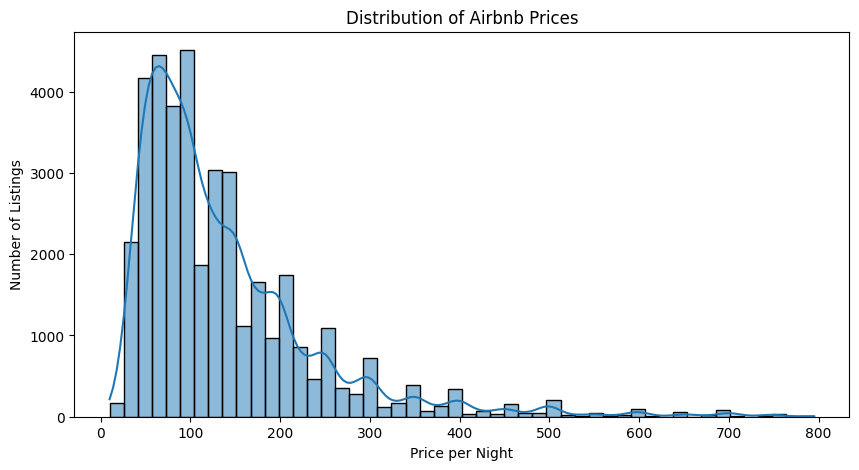

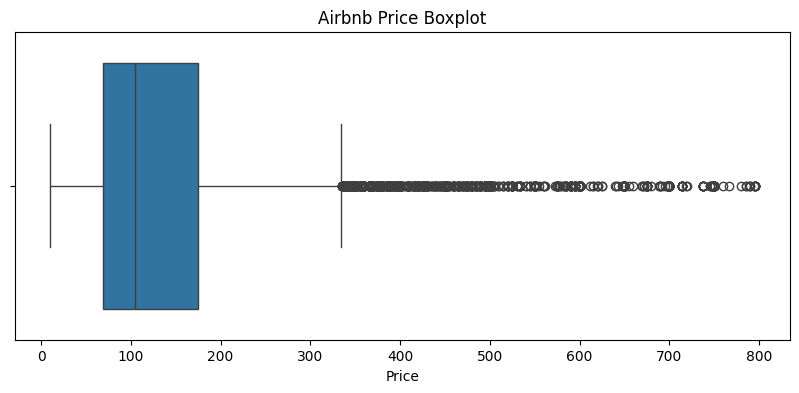

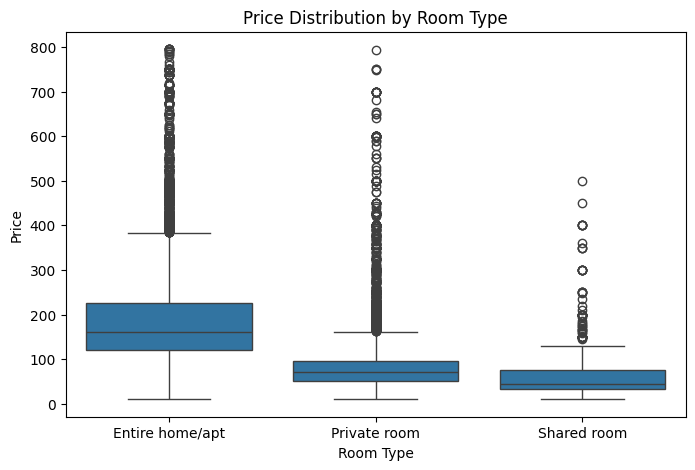

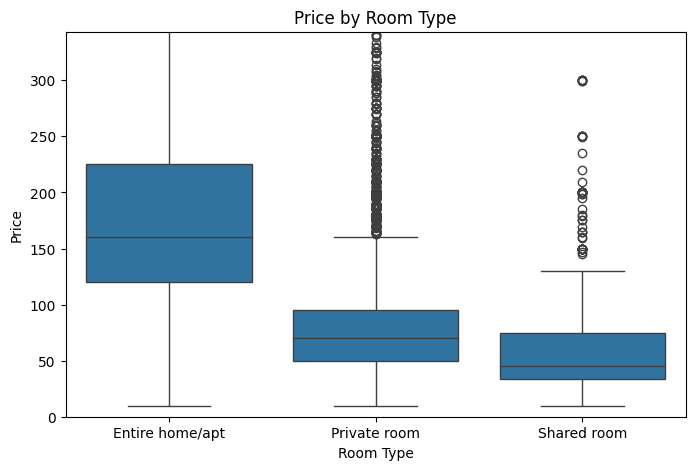

,count,mean,median
neighbourhood_group,,,
Manhattan,17049,172.742507,149.0
Brooklyn,15981,115.863525,90.0
Queens,4533,93.072358,75.0
Staten Island,289,92.993080,75.0
Bronx,863,84.959444,65.0


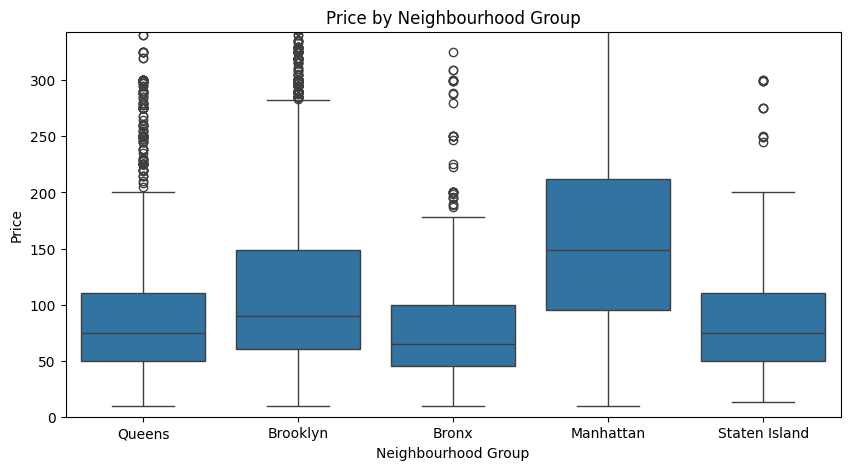

In [75]:
# analyze outliers
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

upper_price = y_train.quantile(0.99)
print("99th percentile:", upper_price)

train_mask = y_train <= upper_price
X_train = X_train[train_mask]
y_train = y_train[train_mask]
print("Training data after outlier removal:")
print(X_train.shape)
print(y_train.shape)

# histogram
plt.figure(figsize=(10, 5))
sns.histplot(y_train, bins=50, kde=True)
plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price per Night")
plt.ylabel("Number of Listings")
plt.show()

# boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=y_train)
plt.title("Airbnb Price Boxplot")
plt.xlabel("Price")
plt.show()


plt.figure(figsize=(8, 5))
sns.boxplot(x=X_train["room_type"], y=y_train)
plt.title("Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price")
plt.show()


plt.figure(figsize=(8, 5))
sns.boxplot(x=X_train["room_type"], y=y_train)
plt.ylim(0, y_train.quantile(0.95))
plt.title("Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price")
plt.show()


price_by_borough = pd.DataFrame({
    "neighbourhood_group": X_train["neighbourhood_group"],
    "price": y_train})
display(
    price_by_borough
    .groupby("neighbourhood_group")["price"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False) )

plt.figure(figsize=(10, 5))
sns.boxplot(data=price_by_borough, x="neighbourhood_group", y="price")
plt.ylim(0, y_train.quantile(0.95))
plt.title("Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Price")
plt.show()

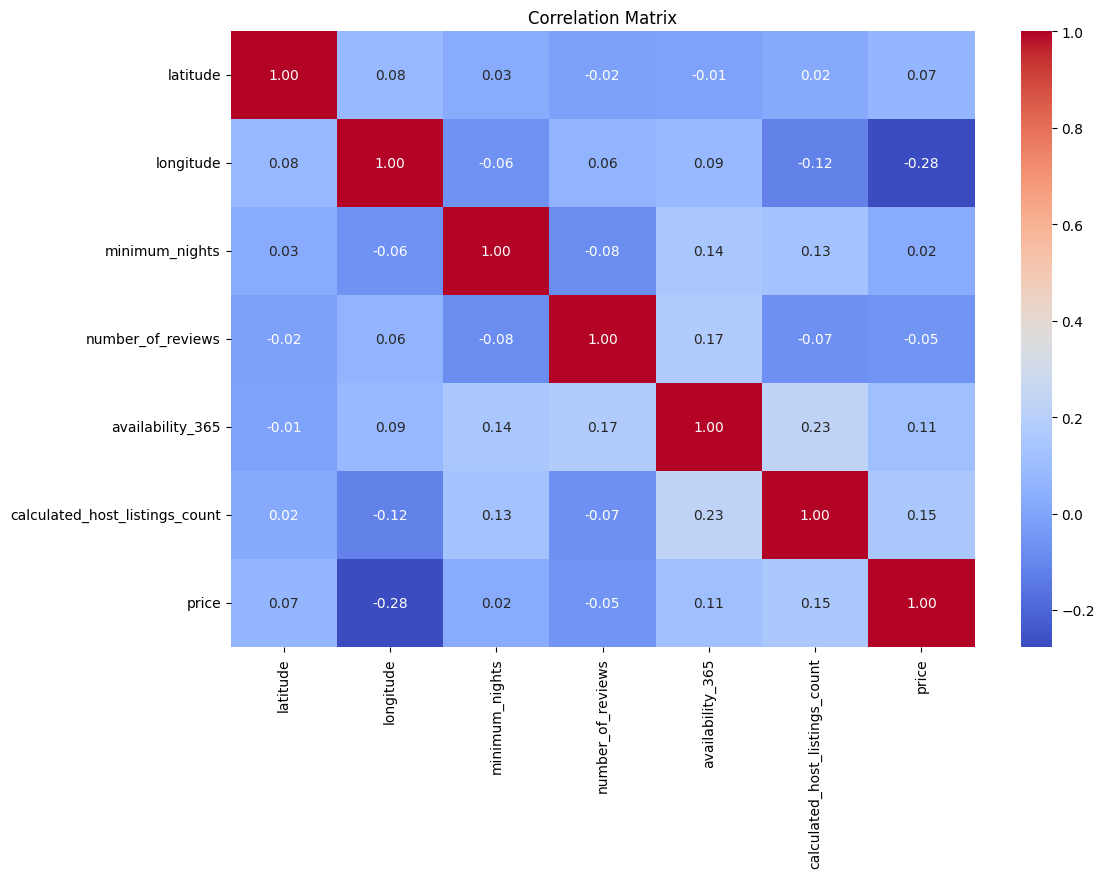

Categorical features:
['neighbourhood_group', 'room_type']

Numerical features:
['minimum_nights', 'number_of_reviews', 'availability_365', 'calculated_host_listings_count', 'latitude', 'longitude']


In [76]:
# correlation analysis
correlation_columns = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "availability_365",
    "calculated_host_listings_count"
]

corr = pd.concat(
    [
        X_train[correlation_columns],
        y_train.rename("price")
    ],
    axis=1
).corr()

# correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# numerical and categorical features
categorical_features = [
    "neighbourhood_group",
    "room_type"
]

numerical_features = [
    col for col in features
    if col not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

In [77]:
# preprocessing pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median") ),
    ("scaler", StandardScaler() )
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent") ),
    ("encoder", OneHotEncoder(handle_unknown="ignore") )
])

# combine preprocessing
preprocessor = ColumnTransformer([
    ("num",
        numeric_pipeline,
        numerical_features
    ),
    ("cat",
        categorical_pipeline,
        categorical_features
    )
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (38715, 14)
Processed testing shape: (9777, 14)


# Task-2

In [78]:
# model pipelines
models = {
    "Linear Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            random_state=42
        ))
    ])
}

# train models
results = []

for name, pipeline in models.items():
    # Train
    pipeline.fit(X_train, y_train)

    # Predictions
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    # Training metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred) )
    train_r2 = r2_score(y_train, y_train_pred)

    # Testing metrics
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred) )
    test_r2 = r2_score(y_test, y_test_pred)

    results.append({
        "Model": name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R²": train_r2,
        "Test R²": test_r2
    })

results_df = pd.DataFrame(results)
display(results_df.sort_values("Test RMSE") )

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
1,Random Forest,16.749447,58.299221,27.547279,181.051898,0.928663,0.181241
2,Gradient Boosting,46.118080,59.853557,75.093018,183.667935,0.469905,0.157410
0,Linear Regression,52.311761,65.516630,82.515886,188.121800,0.359926,0.116049


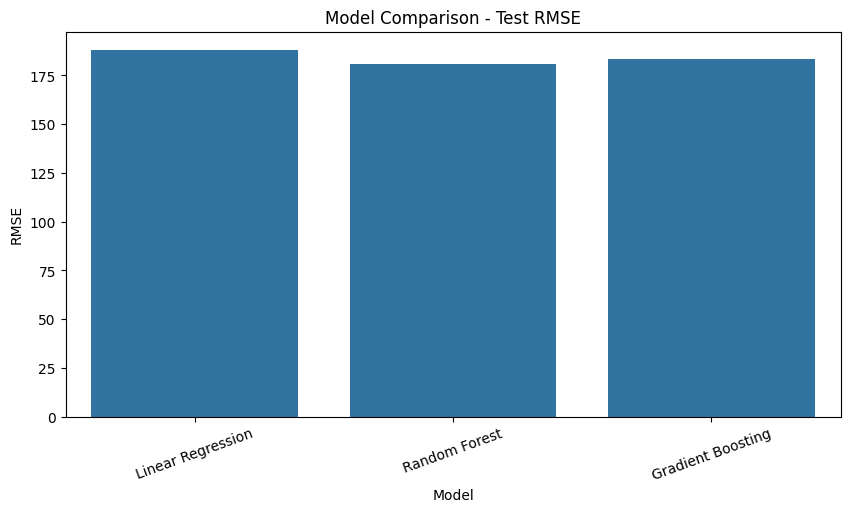

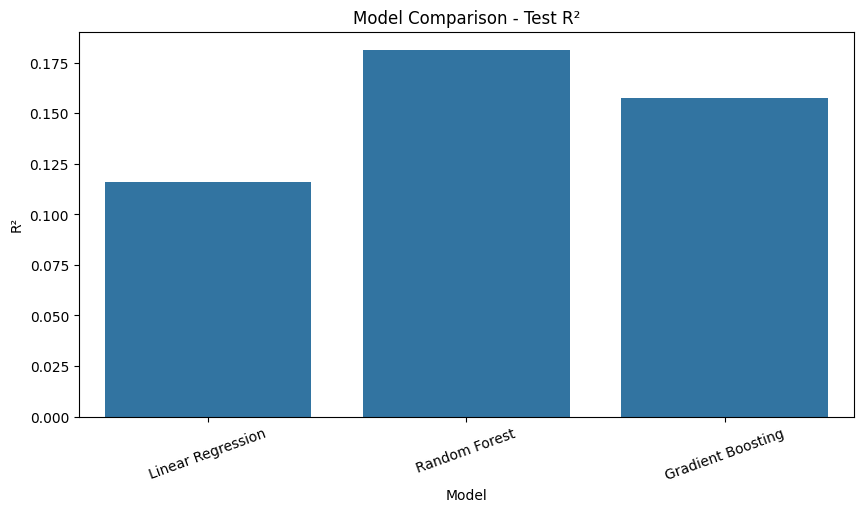

,Model,Train RMSE,Test RMSE,Train R²,Test R²,RMSE Gap,R² Gap
0,Linear Regression,82.515886,188.121800,0.359926,0.116049,105.605914,0.243877
1,Random Forest,27.547279,181.051898,0.928663,0.181241,153.504619,0.747422
2,Gradient Boosting,75.093018,183.667935,0.469905,0.157410,108.574917,0.312495


In [79]:
# visualize model comparision
# Test RMSE
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Test RMSE")

plt.xticks(rotation=20)
plt.title("Model Comparison - Test RMSE")
plt.ylabel("RMSE")
plt.show()

# Test R^2
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Test R²")

plt.xticks(rotation=20)
plt.title("Model Comparison - Test R²")
plt.ylabel("R²")
plt.show()

# check overfitting and underfitting
comparison = results_df[
    ["Model", "Train RMSE", "Test RMSE", "Train R²", "Test R²"]
    ].copy()

comparison["RMSE Gap"] = (
    comparison["Test RMSE"] -
    comparison["Train RMSE"] )

comparison["R² Gap"] = (
    comparison["Train R²"] -
    comparison["Test R²"] )

display(comparison)

In [80]:
# MODEL SELECTION
best_model_name = results_df.loc[
    results_df["Test RMSE"].idxmin(), "Model"
]
print("Best initial model:", best_model_name)

best_r2_model = results_df.loc[
    results_df["Test R²"].idxmax(), "Model"
]
print("Best model by R²:", best_r2_model)

# RANDOM FOREST
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

rf_params = {
    "model__n_estimators": [20],
    "model__max_depth": [10]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)

# Train
rf_grid.fit(X_train, y_train)

# BEST MODEL
print("\nBest Parameters:")
print(rf_grid.best_params_)

print("\nBest CV RMSE:")
print(-rf_grid.best_score_)

best_rf = rf_grid.best_estimator_

Best initial model: Random Forest
Best model by R²: Random Forest
Fitting 3 folds for each of 1 candidates, totalling 3 fits

Best Parameters:
{'model__max_depth': 10, 'model__n_estimators': 20}

Best CV RMSE:
74.3222581713503


In [81]:
import joblib
joblib.dump(best_rf, "model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")
print("\n Model saved successfully (compressed & optimized)")


 Model saved successfully (compressed & optimized)
